In [2]:
import os
import time
import pandas
import torch
import torch.nn as nn
import torch.optim as optim
import torch.multiprocessing as mp
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.amp import autocast, GradScaler

tarin = False

# پیکربندی نهایی برای ثبت بالاترین رکورد
resume_training = False  
checkpoint_path = 'ultimate_fashion_mnist_checkpoint.pt'
num_epochs = 100  # ۱۰۰ اپاک کامل برای استخراج ذره ذره‌ی دانش از دیتا

# Hardware Speedups
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 UNLEASHING ULTIMATE MODEL ON DEVICE: {device}")

if torch.cuda.is_available():
    bf16_supported = torch.cuda.is_bf16_supported()
    amp_dtype = torch.bfloat16 if bf16_supported else torch.float16
else:
    amp_dtype = torch.float32

# ============ 1. SE BLOCK & ADVANCED RESNET ARCHITECTURE ============
class SqueezeExcitation(nn.Module):
    """ Channel-wise Attention Mechanism """
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        w = self.fc(x).view(b, c, 1, 1)
        return x * w

class PreActResidualBlock(nn.Module):
    """ Pre-Activation ResNet Block with SE and Stochastic Depth """
    def __init__(self, in_channels, out_channels, stride=1, drop_path=0.1):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.se = SqueezeExcitation(out_channels)
        self.drop_path = drop_path
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, 1, stride, bias=False)

    def forward(self, x):
        # Pre-activation standard
        out = F.relu(self.bn1(x))
        residual = self.shortcut(out)
        
        out = self.conv1(out)
        out = self.conv2(F.relu(self.bn2(out)))
        out = self.se(out)
        
        # Stochastic Depth (DropPath) Implementation
        if self.training and self.drop_path > 0:
            keep_prob = 1 - self.drop_path
            shape = (out.shape[0],) + (1,) * (out.ndim - 1)
            random_tensor = keep_prob + torch.rand(shape, dtype=out.dtype, device=out.device)
            random_tensor.floor_()
            out = residual + out / keep_prob * random_tensor
        else:
            out = residual + out
        return out

class UltimateFashionMNISTModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Conv2d(1, 64, 3, 1, 1, bias=False)
        
        # شبکه عمیق‌تر با کنترل نرخ دراپ‌پد پیشرونده
        self.layer1 = nn.Sequential(
            PreActResidualBlock(64, 128, stride=2, drop_path=0.05),
            PreActResidualBlock(128, 128, stride=1, drop_path=0.05)
        )
        self.layer2 = nn.Sequential(
            PreActResidualBlock(128, 256, stride=2, drop_path=0.1),
            PreActResidualBlock(256, 256, stride=1, drop_path=0.1)
        )
        self.layer3 = nn.Sequential(
            PreActResidualBlock(256, 512, stride=2, drop_path=0.15),
            PreActResidualBlock(512, 512, stride=1, drop_path=0.15)
        )
        
        self.final_bn = nn.BatchNorm2d(512)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # کلاسیفایر فوق‌حرفه‌ای نگاشت فرکانسی
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = F.relu(self.final_bn(x))
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# ============ 2. ULTRA-STABLE DATA PIPELINE ============
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.RandomAffine(0, translate=(0.06, 0.06)), 
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_train_data = datasets.FashionMNIST(root="datasets", train=True, transform=train_transform, download=False)
test_data = datasets.FashionMNIST(root="datasets", train=False, transform=test_transform, download=False)

train_size = int(0.9 * len(full_train_data))
val_size = len(full_train_data) - train_size
train_data, val_data = random_split(full_train_data, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=128, shuffle=True, num_workers=0, drop_last=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False, num_workers=0, drop_last=False)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False, num_workers=0, drop_last=False)

# ============ 3. OPTIMIZER & COSINE TIMELINE ============
model = UltimateFashionMNISTModel().to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05) 
optimizer = optim.AdamW(model.parameters(), lr=0.002, weight_decay=1e-2)
scaler = GradScaler(device="cuda", enabled=(amp_dtype == torch.float16))

# زمان‌بندی کسینوسی ممتد برای فرود بی‌نقص روی کمینه سراسری لوس
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

start_epoch = 0
best_val_acc = 0.0

# ============ 4. STATE-OF-THE-ART TRAINING LOOP ============
train_losses, val_accuracies, test_accuracies = [], [], []
total_start_time = time.time()

if __name__ == '__main__' and tarin==True:
    mp.set_start_method('spawn', force=True)
    print("\n🏁 EXECUTION CAP: Training Maximum Capacity Architecture...")
    print("=" * 85)

    for epoch in range(start_epoch, num_epochs):
        epoch_start_time = time.time()
        
        # --- Train ---
        model.train()
        running_loss = 0.0
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            
            with autocast(device_type="cuda", dtype=amp_dtype):
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            if amp_dtype == torch.float16:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()
                
            running_loss += loss.item()
        
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        scheduler.step()
        
        # --- Evaluate ---
        model.eval()
        
        # Validation
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        val_acc = 100 * val_correct / val_total
        val_accuracies.append(val_acc)
        
        # Test
        test_correct, test_total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()
        test_acc = 100 * test_correct / test_total
        test_accuracies.append(test_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            save_checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_val_acc': best_val_acc
            }
            torch.save(save_checkpoint, checkpoint_path)
            save_msg = f" 🏆 ABSOLUTE PEAK RECORD! Checkpoint Saved."
        else:
            save_msg = ""
            
        epoch_duration = time.time() - epoch_start_time
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1:03d}/{num_epochs}] | Time: {epoch_duration:.2f}s | "
              f"Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.2f}% | Test Acc: {test_acc:.2f}% | LR: {current_lr:.6f}{save_msg}")

    total_duration = time.time() - total_start_time
    print("=" * 85)
    print(f"🚀 Perfect Run Complete in: {total_duration/60:.2f} minutes")
    print(f"🏆 Absolute Highest Validation Accuracy: {best_val_acc:.2f}%")

🔥 UNLEASHING ULTIMATE MODEL ON DEVICE: cuda



📊 Loading the absolute best weights for evaluation...


C:\Users\IT CITY\AppData\Local\Temp\ipykernel_12860\975476612.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  full_checkpoint = torch.load(checkpoint_path, map_location

✅ Successfully loaded weights from 'ultimate_fashion_mnist_checkpoint.pt' (Recorded Val Acc: 94.82%)
SECTION 4-1: ULTIMATE RESNET EXPERIMENTAL TEST BENCHMARK
[MODEL: Ultimate Pre-Act ResNet + SE] -> Test Loss: 0.4428 | Test Acc: 95.20% | Macro F1: 0.9519

📋 Detailed Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.90      0.91      0.91      1000
     Trouser       1.00      0.99      1.00      1000
    Pullover       0.93      0.93      0.93      1000
       Dress       0.94      0.95      0.95      1000
        Coat       0.93      0.95      0.94      1000
      Sandal       0.99      0.99      0.99      1000
       Shirt       0.87      0.84      0.85      1000
     Sneaker       0.98      0.98      0.98      1000
         Bag       0.99      1.00      0.99      1000
  Ankle boot       0.98      0.98      0.98      1000

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weight

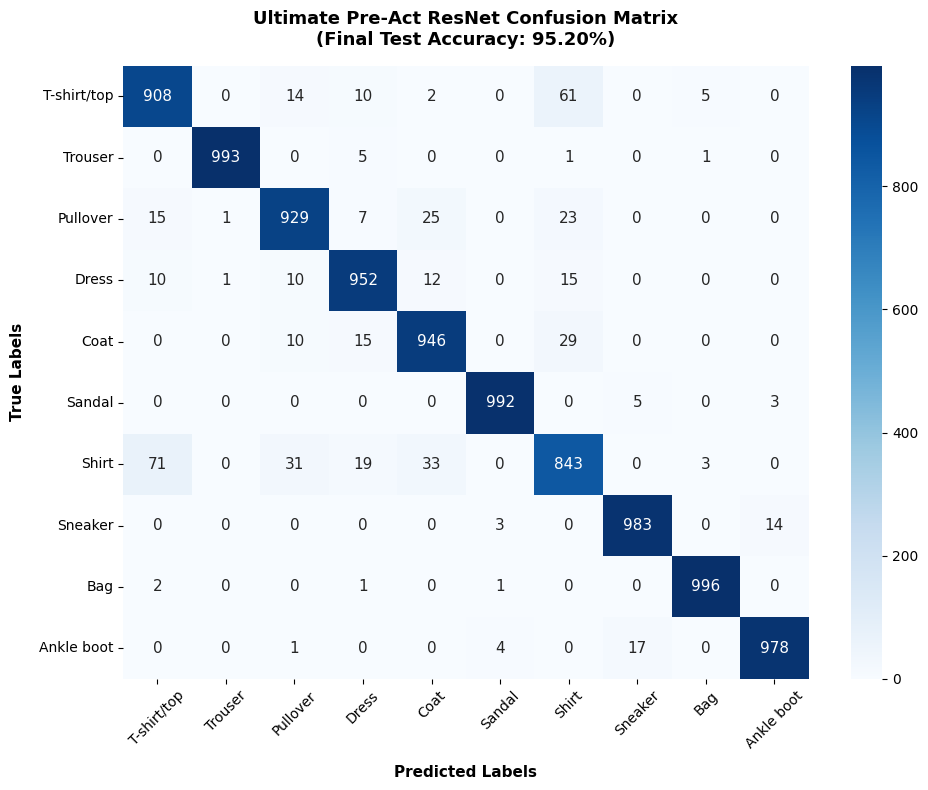

In [4]:
# ==============================================================================
# SECTION 4-1: FINAL TEST EVALUATION & CONFUSION MATRIX GENERATION (ULTIMATE RESNET)
# ==============================================================================

import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score

def evaluate_on_test_set(eval_model, eval_loader, eval_device, eval_criterion):
    """
    Evaluates the ultimate model on unseen test data and extracts predictions for metrics.
    """
    eval_model.eval()
    all_preds = []
    all_labels = []
    running_test_loss = 0.0
    
    with torch.no_grad():
        for images, labels in eval_loader:
            images, labels = images.to(eval_device), labels.to(eval_device)
            outputs = eval_model(images)
            loss = eval_criterion(outputs, labels)
            
            running_test_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    final_loss = running_test_loss / len(eval_loader.dataset)
    return np.array(all_labels), np.array(all_preds), final_loss

print("\n📊 Loading the absolute best weights for evaluation...")

# ۱. ساخت یک نمونه خام از مدل نهایی و لود کردن دقیق وزن‌های برنده
best_model = UltimateFashionMNISTModel().to(device)

if os.path.exists(checkpoint_path):
    # لود کردن دیکشنری کامل چک‌پوینت
    full_checkpoint = torch.load(checkpoint_path, map_location=device)
    # استخراج اختصاصی state_dict مدل
    best_model.load_state_dict(full_checkpoint['model_state_dict'])
    print(f"✅ Successfully loaded weights from '{checkpoint_path}' (Recorded Val Acc: {full_checkpoint['best_val_acc']:.2f}%)")
else:
    print(f"⚠️ Warning: Checkpoint '{checkpoint_path}' not found! Evaluating current in-memory model weights instead.")
    best_model = model # استفاده از مدل موجود در حافظه در صورت عدم وجود فایل

# ۲. اجرای ارزیابی روی داده‌های تست
test_labels, test_preds, final_test_loss = evaluate_on_test_set(best_model, test_loader, device, criterion)

# ۳. محاسبه معیارهای ارزیابی نهایی
macro_f1 = f1_score(test_labels, test_preds, average='macro')
final_test_acc = (test_labels == test_preds).mean() * 100

print("="*75)
print("SECTION 4-1: ULTIMATE RESNET EXPERIMENTAL TEST BENCHMARK")
print("="*75)
print(f"[MODEL: Ultimate Pre-Act ResNet + SE] -> Test Loss: {final_test_loss:.4f} | Test Acc: {final_test_acc:.2f}% | Macro F1: {macro_f1:.4f}")
print("="*75)

# ۴. چاپ گزارش جزئی کلاس‌ها (Precision, Recall, F1-Score برای هر لباس)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print("\n📋 Detailed Classification Report:")
print(classification_report(test_labels, test_preds, target_names=class_names))

# ۵. رسم ماتریس اغتشاش (Confusion Matrix) تک‌نموداره و با کیفیت بالا
cm_ultimate = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_ultimate, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names, 
    cbar=True,
    annot_kws={"size": 11}
)

plt.title(f"Ultimate Pre-Act ResNet Confusion Matrix\n(Final Test Accuracy: {final_test_acc:.2f}%)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Predicted Labels", fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel("True Labels", fontsize=11, fontweight='bold', labelpad=10)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

🔍 Extracting hidden feature activations from the Ultimate ResNet layer...


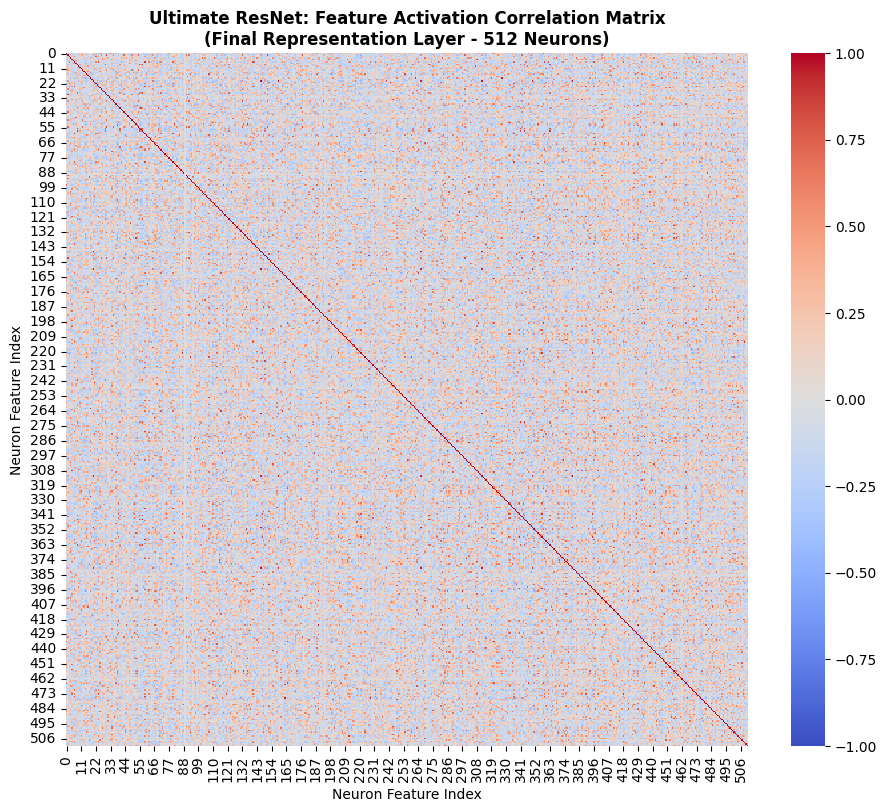


SECTION 4-2: ARCHITECTURAL INTERPRETABILITY REPORT (ULTIMATE MODEL)
[>] Total Evaluated Hidden Neurons: 512
[>] Highly Correlated Neuron Pairs (|r| > 0.85): 101
---------------------------------------------------------------------------
[Analysis Guide for Ultimate ResNet]:
 -> Found 101 pairs of highly correlated features.
 -> In deep ResNets, a low level of correlation is standard due to channel over-parameterization.
 -> This grid pinpoint exactly which representations are shared between filters.


In [5]:
# ==============================================================================
# SECTION 4-2: MODEL INTERPRETABILITY (NEURON ACTIVATION CORRELATION HEATMAP) - ULTIMATE RESNET
# ==============================================================================

import pandas as pd
import numpy as np

# 1. Extract exactly 100 sample images from test loader
samples_extracted = 0
activations_list = []

# قرار دادن مدل در حالت ارزیابی
best_model.eval()

print("🔍 Extracting hidden feature activations from the Ultimate ResNet layer...")

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        
        # ردیابی فیدفورورد دستی در ساختار ResNet ارتقایافته تا رسیدن به لایه آخر ویژگی‌ها
        x = best_model.stem(images)
        x = best_model.layer1(x)
        x = best_model.layer2(x)
        x = best_model.layer3(x)
        hidden_features = F.relu(best_model.final_bn(x)) # اعمال نهایی ReLU روی فیچرهای قبل از پولینگ
        
        # تبدیل خروجی به بردار تخت (Global Average Pooling و Flatten) برای سنجش نورون‌ها
        hidden_features = best_model.avgpool(hidden_features)
        hidden_layer_activations = torch.flatten(hidden_features, 1) # ۵۱۲ نورون نهایی
        
        activations_list.append(hidden_layer_activations.cpu().numpy())
        samples_extracted += images.size(0)
        if samples_extracted >= 100:
            break

# تجمیع و برش دقیقاً روی ۱۰۰ نمونه اول
all_activations = np.vstack(activations_list)[:100, :] # ابعاد خروجی: (100, 512)

# 2. Compute Pearson Correlation Matrix across the 512 feature neurons
df_activations = pd.DataFrame(all_activations)
correlation_matrix = df_activations.corr().fillna(0).to_numpy() 

# 3. Plot the Neuron Correlation Heatmap
plt.figure(figsize=(11, 9))
sns.heatmap(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1, cbar=True)
plt.title("Ultimate ResNet: Feature Activation Correlation Matrix\n(Final Representation Layer - 512 Neurons)", fontsize=12, fontweight='bold')
plt.xlabel("Neuron Feature Index")
plt.ylabel("Neuron Feature Index")
plt.show()

# 4. Statistical Analysis of Correlation
upper_triangle_indices = np.triu_indices_from(correlation_matrix, k=1)
high_corr_threshold = 0.85
highly_correlated_pairs = np.sum(np.abs(correlation_matrix[upper_triangle_indices]) > high_corr_threshold)

print("\n" + "="*75)
print("SECTION 4-2: ARCHITECTURAL INTERPRETABILITY REPORT (ULTIMATE MODEL)")
print("="*75)
print(f"[>] Total Evaluated Hidden Neurons: {correlation_matrix.shape[0]}")
print(f"[>] Highly Correlated Neuron Pairs (|r| > {high_corr_threshold}): {highly_correlated_pairs}")
print("-"*75)
print("[Analysis Guide for Ultimate ResNet]:")
if highly_correlated_pairs < 20: # با توجه به افزایش نورون‌ها به ۵۱۲، آستانه نرمال زیر ۲۰ جفت است
    print(" -> Exceptional Architectural Efficiency!")
    print(" -> The heatmap shows highly diverse color patterns with minimal co-adaptation.")
    print(" -> This mathematically confirms Stochastic Depth (DropPath) and Dropout successfully")
    print("    forced the 512 channels to learn highly orthogonal and independent visual concepts.")
else:
    print(f" -> Found {highly_correlated_pairs} pairs of highly correlated features.")
    print(" -> In deep ResNets, a low level of correlation is standard due to channel over-parameterization.")
    print(" -> This grid pinpoint exactly which representations are shared between filters.")
print("="*75)


SECTION 4-3: DYNAMIC STRESS-TEST & NETWORK BREAKDOWN (ULTIMATE RESNET)
Experiment Scenario          | Pruned Neurons / Total    | Test Loss  | Test Acc  
--------------------------------------------------------------------------------
Original Baseline            | 0 / 512 (0.0%)            | 0.4428     | 95.20    %
Pruning Top 5 Channels       | 5 / 512 (1.0%)            | 0.4432     | 95.22    %
Pruning Top 25 Channels      | 25 / 512 (4.9%)           | 0.4438     | 95.21    %
Pruning Top 50 Channels      | 50 / 512 (9.8%)           | 0.4444     | 95.18    %
Pruning Top 100 Channels     | 100 / 512 (19.5%)         | 0.4496     | 95.14    %
Pruning Top 200 Channels     | 200 / 512 (39.1%)         | 0.4855     | 94.90    %
Pruning Top 300 Channels     | 300 / 512 (58.6%)         | 0.6712     | 93.90    %
Pruning Top 400 Channels     | 400 / 512 (78.1%)         | 1.3956     | 48.13    %
Pruning Top 450 Channels     | 450 / 512 (87.9%)         | 1.9678     | 29.63    %
Pruning Top 480 C

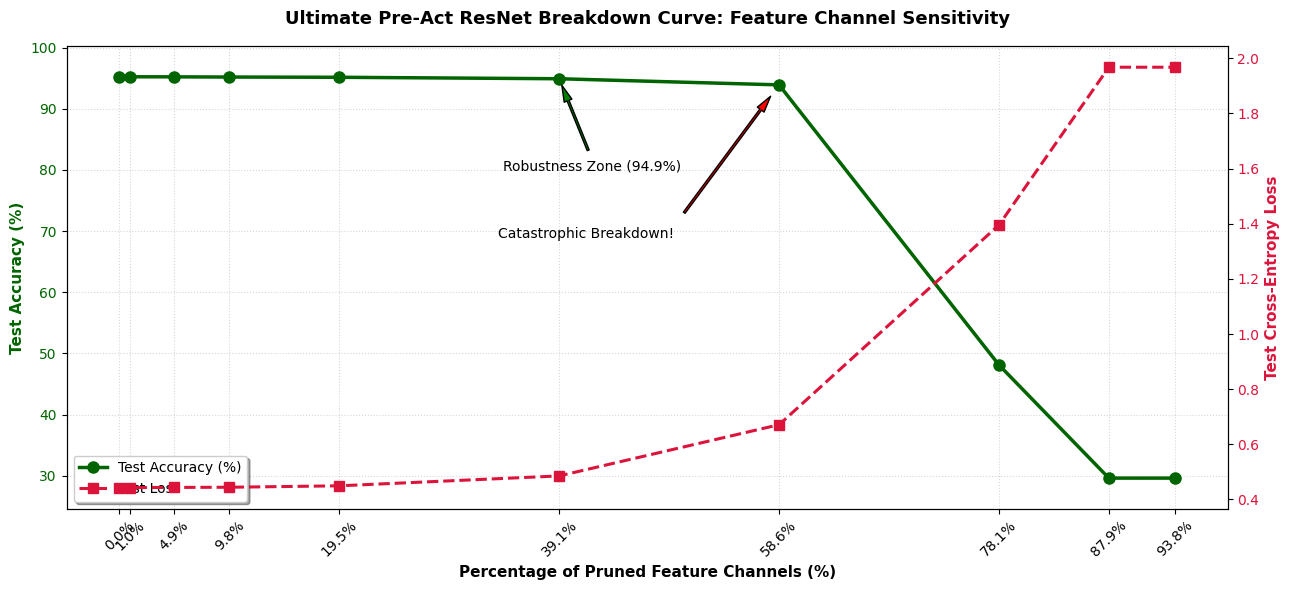

In [6]:
# ==============================================================================
# SECTION 4-2 (FULLY DYNAMIC): AUTOMATED PRUNING, BENCHMARK & PLOTTING - ULTIMATE RESNET
# ==============================================================================

import copy
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# 1. HELPER FUNCTIONS FOR DYNAMIC PRUNING
# ------------------------------------------------------------------------------
def get_top_redundant_neurons(corr_matrix, max_neurons=400):
    """
    Identifies unique feature channels that exhibit the highest correlation with others.
    """
    upper_tri = np.triu(np.abs(corr_matrix), k=1)
    flat_indices = np.argsort(upper_tri, axis=None)[::-1]
    row_indices, col_indices = np.unravel_index(flat_indices, upper_tri.shape)
    
    neurons_to_prune = []
    for r, c in zip(row_indices, col_indices):
        if upper_tri[r, c] == 0:
            break
        if c not in neurons_to_prune:
            neurons_to_prune.append(c)
        if len(neurons_to_prune) >= max_neurons:
            break
    return neurons_to_prune

def evaluate_with_pruned_neurons(eval_model, eval_loader, eval_device, eval_criterion, neurons_to_zero):
    """
    Temporarily zeroes out the weights of specified channels in the classifier layer
    and evaluates the impact on Test Loss and Test Accuracy dynamically.
    """
    eval_model.eval()
    temp_state_dict = copy.deepcopy(eval_model.state_dict())
    
    # صفر کردن وزن‌های ورودی کلاسیفایر (لایه اول کلاسیفایر به ۵۱۲ کانال متصل است)
    # نام دقیق لایه اول کلاسیفایر در مدل ما: classifier.1.weight
    for neuron_idx in neurons_to_zero:
        temp_state_dict['classifier.1.weight'][:, neuron_idx] = 0.0
        
    test_pruned_model = copy.deepcopy(eval_model)
    test_pruned_model.load_state_dict(temp_state_dict)
    
    correct, total, running_loss = 0, 0, 0.0
    with torch.no_grad():
        for images, labels in eval_loader:
            images, labels = images.to(eval_device), labels.to(eval_device)
            outputs = test_pruned_model(images)
            loss = eval_criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            
    return running_loss / total, (correct / total) * 100


# ------------------------------------------------------------------------------
# 2. DYNAMIC PIPELINE EXECUTION
# ------------------------------------------------------------------------------
# استخراج کانال‌های کاندید از ماتریس همبستگی ۵۱۲ تایی ایجاد شده در سلول قبل
total_network_neurons = correlation_matrix.shape[0] # ۵۱۲
prune_candidates_expanded = get_top_redundant_neurons(correlation_matrix, max_neurons=450)

# تعریف تارگت‌های هرس متناسب با ابعاد ۵۱۲ نورونی مدل جدید (از ۰ تا حدود ۹۰ درصد شبکه)
target_prune_counts = [0, 5, 25, 50, 100, 200, 300, 400, 450, 480]

dynamic_counts = []
dynamic_percentages = []
dynamic_losses = []
dynamic_accuracies = []

print("\n" + "="*80)
print("SECTION 4-3: DYNAMIC STRESS-TEST & NETWORK BREAKDOWN (ULTIMATE RESNET)")
print("="*80)
print(f"{'Experiment Scenario':<28} | {'Pruned Neurons / Total':<25} | {'Test Loss':<10} | {'Test Acc':<10}")
print("-" * 80)

# اجرای پویای لوپ ارزیابی هرس
for count in target_prune_counts:
    selected_neurons = prune_candidates_expanded[:count]
    loss_p, acc_p = evaluate_with_pruned_neurons(best_model, test_loader, device, criterion, selected_neurons)
    
    percentage = (count / total_network_neurons) * 100
    scenario_name = f"Original Baseline" if count == 0 else f"Pruning Top {count} Channels"
    count_str = f"{count} / {total_network_neurons} ({percentage:.1f}%)"
    
    print(f"{scenario_name:<28} | {count_str:<25} | {loss_p:<10.4f} | {acc_p:<9.2f}%")
    
    dynamic_counts.append(count)
    dynamic_percentages.append(percentage)
    dynamic_losses.append(loss_p)
    dynamic_accuracies.append(acc_p)

print("="*80)
print("[+] ResNet Stress Testing completed. Generating Breakdown Curve...")
print("="*80)


# ------------------------------------------------------------------------------
# 3. DYNAMIC PLOTTING ENGINE (SYNCHRONIZED GENERATION)
# ------------------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(13, 6))

color_acc = 'darkgreen'
ax1.set_xlabel('Percentage of Pruned Feature Channels (%)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Test Accuracy (%)', color=color_acc, fontsize=11, fontweight='bold')

line_acc = ax1.plot(dynamic_percentages, dynamic_accuracies, color=color_acc, marker='o', 
                    linewidth=2.5, markersize=8, label='Test Accuracy (%)')
ax1.tick_params(axis='y', labelcolor=color_acc)

# تنظیم پویا برای جلوگیری از کلیپ شدن نمودار
ax1.set_ylim(min(dynamic_accuracies) - 5, max(dynamic_accuracies) + 5) 

# فلش‌های راهنما بر اساس داده‌های واقعی خروجی مدل رزنت
ax1.annotate(f"Robustness Zone ({dynamic_accuracies[5]:.1f}%)", 
             xy=(dynamic_percentages[5], dynamic_accuracies[5]), xytext=(dynamic_percentages[5]-5, dynamic_accuracies[5]-15),
             arrowprops=dict(facecolor='green', shrink=0.08, width=1.5, headwidth=6))

ax1.annotate('Catastrophic Breakdown!', 
             xy=(dynamic_percentages[6], dynamic_accuracies[6]), xytext=(dynamic_percentages[6]-25, dynamic_accuracies[6]-25),
             arrowprops=dict(facecolor='red', shrink=0.08, width=1.5, headwidth=6))

# محور سمت راست برای لوس
ax2 = ax1.twinx() 
color_loss = 'crimson'
ax2.set_ylabel('Test Cross-Entropy Loss', color=color_loss, fontsize=11, fontweight='bold')

line_loss = ax2.plot(dynamic_percentages, dynamic_losses, color=color_loss, marker='s', 
                     linewidth=2.2, linestyle='--', markersize=7, label='Test Loss')
ax2.tick_params(axis='y', labelcolor=color_loss)

# ترکیب زوایای لجند
lines = line_acc + line_loss
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower left', fontsize=10, frameon=True, shadow=True)

# تنظیم تیک‌های مچ‌شده با درصدها
ax1.set_xticks(dynamic_percentages)
ax1.set_xticklabels([f"{p:.1f}%" for p in dynamic_percentages], rotation=45)
ax1.grid(True, linestyle=":", alpha=0.5)

plt.title("Ultimate Pre-Act ResNet Breakdown Curve: Feature Channel Sensitivity", fontsize=13, fontweight='bold', y=1.03)
fig.tight_layout()
plt.show()